<a href="https://colab.research.google.com/github/yulia3006/ml-basics/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%96%2012.2_%D0%93%D0%B5%D0%BE%D0%BC%D0%B0%D1%80%D0%BA%D0%B5%D1%82%D0%B8%D0%BD%D0%B3%D0%BE%D0%B2%D0%BE%D0%B5_%D0%B8%D1%81%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D1%82%D0%B5%D1%80%D1%80%D0%B8%D1%82%D0%BE%D1%80%D0%B8%D0%B9_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геомаркетинговое исследование территорий с применением методов машинного обучения**


## **Цель работы**


Овладеть методами пространственного анализа и машинного обучения для решения практической задачи определения оптимальных локаций размещения коммерческих объектов.

## **Введение**


В современном бизнесе местоположение коммерческого объекта играет ключевую роль в его успешности. Геомаркетинговый анализ позволяет объективно оценить привлекательность различных локаций, опираясь на количественные показатели и алгоритмы машинного обучения.

В рамках данной работы вы примените полный цикл пространственного анализа, включая сбор данных из открытых источников, обработку и агрегацию пространственной информации, обучение моделей машинного обучения и визуализацию результатов.

## **Задание**


Провести геомаркетинговое исследование для выбора оптимальных локаций размещения новых точек определенного типа бизнеса на территории выбранного города.

## **Порядок выполнения работы**

### **Часть 1. Подготовка данных и определение задачи**



1. **Индивидуальный выбор территории и типа бизнеса**:
   - Выберите город/район для проведения анализа (например, центральная часть Москвы, Санкт-Петербурга или любого другого крупного города)
   - Определите тип бизнеса для анализа (аптеки, продуктовые магазины, пункты выдачи заказов, рестораны определенной кухни и т.д.)
   - Обоснуйте свой выбор: почему данная территория и тип бизнеса интересны для анализа?

2. **Определение ключевых факторов успешности**:
   - Самостоятельно сформулируйте не менее 5 факторов, которые могут влиять на успешность выбранного типа бизнеса
   - Для каждого фактора определите, какими данными из OpenStreetMap его можно количественно описать
   - Составьте таблицу соответствия между факторами и тегами OpenStreetMap

3. **Сбор исходных данных**:
   - Настройте необходимые библиотеки из теоретического материала
   - Определите необходимую область интереса (ROI) с помощью интерактивной карты
   - Загрузите данные о существующих объектах вашего типа бизнеса и объектах инфраструктуры, связанных с выделенными вами факторами

In [ ]:
пункт 1
Территория: г. Александров, Владимирская область
Тип бизнеса: Пункты выдачи заказов (ПВЗ) маркетплейсов и логистических операторов (Wildberries, Ozon, Яндекс.Маркет, СДЭК и др.)
Обоснование выбора:
Почему выбран г. Александров и ПВЗ?
1. Город:  мой родной город+население ~55 тыс. человек достаточно для анализа, но не перегружает вычисления.
Есть чёткое деление: исторический центр + новые жилые районы, разная плотность людей и трафика.
2. Бизнес (пункты выдачи заказов):
Успех ПВЗ сильно зависит от места: чем ближе к людям и удобнее подъезд, тем выше спрос.
Важно избегать мест, где уже много конкурентов в шаговой доступности.
3. Удобство для учебной работы:
Город компактный, данные из OSM загружаются быстро.
Есть дороги, жилые дома, магазины, можно отработать все этапы: от сбора данных до построения прогнозной модели.

In [ ]:
пункт 2
№ |                Фактор успешности ПВЗ         | Количественная метрика                               | Соответствующие теги OpenStreetMap
1 | Плотность жилого фонда (потенциальный спрос) | Количество жилых зданий/блоков в радиусе 500 м       | building=residential, building=apartments, landuse=residential
2 |                Транспортная доступность      | Длина улично-дорожной сети, наличие остановок ОТ     | highway=* (все типы дорог), public_transport=stop_position, railway=station
3 |                Уровень конкуренции           |  Количество действующих ПВЗ в радиусе 800 м          | shop=parcel_pickup, name~"Wildberries|Ozon|Яндекс|СДЭК"
4 |           Коммерческая активность зоны       |  Наличие супермаркетов, рынков, ТЦ                   | shop=supermarket, amenity=marketplace, shop=mall, landuse=commercial
5 |          Инфраструктура для посетителей      | Наличие парковок, пешеходных зон, фасадная видимость | amenity=parking, highway=pedestrian, building=retail

In [2]:
!pip install osmnx geopandas pandas numpy leafmap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.5 MB/s eta 0:00:00
  Attempting uninstall: duckdb
    Found existing installa

In [3]:
!pip install osmnx geopandas leafmap mapclassify h3pandas h3~=3.0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import leafmap
import osmnx as ox
from shapely.geometry import box, Polygon
from sklearn.preprocessing import MinMaxScaler
import h3
import h3pandas

INFO: pip is looking at multiple versions of h3pandas to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.8 MB/s eta 0:00:00
  Created wheel for h3pandas: filename=h3pandas-0.2.6-py3-none-any.whl size=19688 sha256=0b603d5e6fd74f42c30dfe854a2f99744db76957e34a8d0867e19b5d0bca200c
  Stored in directory: /root/.cache/pip/wheels/b8/92/37/51119668d260605aa3e77ff7bc342ad2add69eaac0d77d5744
Successfully built h3pandas


In [4]:
m = leafmap.Map(draw_control=True, basemap='CartoDB.Positron')
m

bbox = m.user_roi_bounds()
if bbox:
    print(f"Выбранный bounding box: {bbox}")
else:
    bbox = [38.58, 56.19, 38.84, 38.30]
    print(f" Область не выбрана. Используем значение по умолчанию для г. Александров: {bbox}")

pvz_tags = {
    'shop': ['parcel_pickup', 'outpost', 'convenience'],
    'brand': ['Ozon', 'Wildberries', 'СДЭК', 'Яндекс', 'Boxberry'],
    'name': ['Ozon', 'Wildberries', 'СДЭК', 'Яндекс', 'ПВЗ']
}

try:
    pvz_gdf = ox.features_from_place("Александров, Владимирская область, Россия", tags=pvz_tags)
    pvz_gdf.crs = "EPSG:4326"
    print(f" Найдено объектов ПВЗ: {len(pvz_gdf)}")
except Exception as e:
    print(f"Не удалось загрузить данные по тегам: {e}")
    pvz_gdf = gpd.GeoDataFrame(crs="EPSG:4326")

center_lat = (bbox[1] + bbox[3]) / 2
center_lon = (bbox[0] + bbox[2]) / 2

m2 = leafmap.Map(
    center=[center_lat, center_lon],
    zoom=12,
    basemap='CartoDB.Positron'
)

if not pvz_gdf.empty:
    m2.add_gdf(
        pvz_gdf,
        layer_name='ПВЗ маркетплейсов',
        info_mode='on_click',
        color='red',
        opacity=0.8
    )

m2

 Область не выбрана. Используем значение по умолчанию для г. Александров: [38.58, 56.19, 38.84, 38.3]
 Найдено объектов ПВЗ: 67


Map(center=[47.245, 38.71], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

### **Часть 2. Пространственное агрегирование и создание признаков**


1. **Создание гексагональной сетки**:
   - Самостоятельно определите оптимальную детализацию сетки H3 для вашего анализа
   - Обоснуйте выбор разрешения (resolution) сетки с учётом масштаба вашей территории и специфики бизнеса
   - Покройте территорию гексагональной сеткой выбранного разрешения

2. **Инженерия пространственных признаков**:
   - Определите радиусы для анализа ближнего и среднего окружения (могут отличаться от предложенных в теории в зависимости от специфики вашего бизнеса)
   - Разработайте и реализуйте не менее 10 пространственных признаков, описывающих характеристики каждой ячейки
   - **Дополнительное задание**: придумайте и реализуйте не менее 2 пространственных признаков, которых нет в теоретическом материале

3. **Анализ полученных признаков**:
   - Рассчитайте базовую статистику по каждому признаку
   - Исследуйте корреляции между признаками
   - Выявите и обработайте выбросы и пропущенные значения, если они имеются

In [16]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import osmnx as ox
import leafmap
import h3
import h3.api.numpy_int as h3
from shapely.geometry import box, Polygon
from sklearn.preprocessing import MinMaxScaler

# Параметры
place_name = 'Александров, Владимирская область, Россия'
res = 8
crs_proj = "EPSG:3857"       # метрическая проекция

In [57]:
# 1. Получаем полигон города
area_gdf = ox.geocode_to_gdf(place_name).to_crs("EPSG:4326")
bbox = area_gdf.total_bounds
print("Границы города (lon_min, lat_min, lon_max, lat_max):", bbox)

# 2. Буфер для гарантии покрытия
bbox_poly = box(bbox[0] - 0.01, bbox[1] - 0.01, bbox[2] + 0.01, bbox[3] + 0.01)

# 3. Генерация H3-индексов
try:
    h3_ids = list(h3.polygon_to_cells(bbox_poly.__geo_interface__, res))
except AttributeError:
    h3_ids = list(h3.polyfill(bbox_poly.__geo_interface__, res))

print(f"Сгенерировано индексов с res={res}: {len(h3_ids)}")

# Если мало или ноль – пробуем меньшее разрешение
if len(h3_ids) < 5:
    print(f"Мало ячеек, пробуем res=7...")
    res = 7
    try:
        h3_ids = list(h3.polygon_to_cells(bbox_poly.__geo_interface__, res))
    except AttributeError:
        h3_ids = list(h3.polyfill(bbox_poly.__geo_interface__, res))
    print(f"Сгенерировано индексов с res=7: {len(h3_ids)}")

if len(h3_ids) == 0:
    raise ValueError("Не удалось создать H3-индексы.")

# 4. Геометрии гексагонов
h3_geoms = []
for idx in h3_ids:
    try:
        # H3 возвращает [(lat, lon), ...], нужно перевернуть в (lon, lat) для Shapely
        boundary = h3.cell_to_boundary(idx, geo_json=True)
        # boundary это список [lat, lon], меняем на [lon, lat]
        boundary_flipped = [[coord[1], coord[0]] for coord in boundary]
    except AttributeError:
        boundary = h3.h3_to_geo_boundary(idx, geo_json=True)
        boundary_flipped = [[coord[1], coord[0]] for coord in boundary]

    h3_geoms.append(Polygon(boundary_flipped))

# 5. GeoDataFrame в WGS84
h3_gdf = gpd.GeoDataFrame({'h3_index': h3_ids, 'geometry': h3_geoms}, crs="EPSG:4326")

# 6. Обрезка по реальной границе города
h3_gdf = h3_gdf[h3_gdf.intersects(area_gdf.unary_union)].reset_index(drop=True)
print(f"После обрезки по границе города: {len(h3_gdf)} ячеек")

if len(h3_gdf) == 0:
    print("Ни одна ячейка не пересеклась, берём все в буфере")
    h3_gdf = gpd.GeoDataFrame({'h3_index': h3_ids, 'geometry': h3_geoms}, crs="EPSG:4326")

# 7. Переводим в метрическую проекцию
h3_gdf = h3_gdf.to_crs(crs_proj)
print(f"Финальное количество ячеек: {len(h3_gdf)}")

# 8. ПРОВЕРКА - должны совпадать с OSM!
print(f"H3 ячейки: {h3_gdf.total_bounds}")
print(f"Должно быть близко к: {area_gdf.to_crs(crs_proj).total_bounds}")

# 9. Визуализация для проверки
h3_viz = h3_gdf.to_crs("EPSG:4326")
center_lat = (bbox[1] + bbox[3]) / 2
center_lon = (bbox[0] + bbox[2]) / 2
m_grid = leafmap.Map(center=[center_lat, center_lon], zoom=12, basemap='CartoDB.Positron')
m_grid.add_gdf(h3_viz, layer_name="H3 сетка", style={"color": "#3388ff", "weight": 1.5, "fillOpacity": 0.1})
m_grid

Границы города (lon_min, lat_min, lon_max, lat_max): [38.6589017 56.362759  38.7771939 56.4210093]
Сгенерировано индексов с res=8: 127
После обрезки по границе города: 70 ячеек
Финальное количество ячеек: 70
H3 ячейки: [4303138.67459836 7629385.47741127 4317278.1805409  7645116.70560719]
Должно быть близко к: [4303489.25187122 7630972.26358706 4316657.47934003 7642687.31992977]


Map(center=[np.float64(56.391884149999996), np.float64(38.7180478)], controls=(ZoomControl(options=['position'…

In [58]:
print("Загрузка данных OSM для Александрова...")

# Целевые объекты (существующие ПВЗ)
target_gdf = ox.features_from_place(
    place_name,
    tags={'shop': ['parcel_pickup', 'outpost'], 'brand': ['Ozon', 'Wildberries', 'СДЭК', 'Яндекс', 'Boxberry']}
)
target_gdf = target_gdf.to_crs(crs_proj)
print(f"  ПВЗ: {len(target_gdf)}")

# Конкуренты (все ПВЗ – для расчёта конкуренции)
competitors_gdf = target_gdf.copy()
print(f"  Конкуренты (все ПВЗ): {len(competitors_gdf)}")

# Жилые здания
houses_gdf = ox.features_from_place(place_name, tags={'building': ['apartments', 'residential', 'house']})
houses_gdf = houses_gdf.to_crs(crs_proj)
print(f"  Жилых зданий: {len(houses_gdf)}")

# Общественный транспорт
transport_gdf = ox.features_from_place(place_name, tags={'public_transport': 'stop_position', 'highway': 'bus_stop'})
transport_gdf = transport_gdf.to_crs(crs_proj)
print(f"  Объектов транспорта: {len(transport_gdf)}")

# Социальная инфраструктура
social_gdf = ox.features_from_place(place_name, tags={'amenity': ['school', 'kindergarten', 'hospital', 'clinic', 'pharmacy']})
social_gdf = social_gdf.to_crs(crs_proj)
print(f"  Соцобъектов: {len(social_gdf)}")

# Дороги (проходимость)
roads_gdf = ox.features_from_place(place_name, tags={'highway': ['primary', 'secondary', 'tertiary', 'residential']})
roads_gdf = roads_gdf.to_crs(crs_proj)
print(f"  Протяжённость дорог: {roads_gdf.geometry.length.sum()/1000:.1f} км")

# Парковки
parking_gdf = ox.features_from_place(place_name, tags={'amenity': 'parking'})
parking_gdf = parking_gdf.to_crs(crs_proj)
print(f"  Парковок: {len(parking_gdf)}")

# Торговые центры и крупные магазины
malls_gdf = ox.features_from_place(place_name, tags={'shop': 'mall', 'landuse': 'retail'})
malls_gdf = malls_gdf.to_crs(crs_proj)
print(f"  ТЦ и крупных магазинов: {len(malls_gdf)}")


Загрузка данных OSM для Александрова...
  ПВЗ: 43
  Конкуренты (все ПВЗ): 43
  Жилых зданий: 246
  Объектов транспорта: 52
  Соцобъектов: 45
  Протяжённость дорог: 286.7 км
  Парковок: 53
  ТЦ и крупных магазинов: 12


In [59]:
def analyze_hex_cell(geometry):
    RADIUS_NEAR = 300   # ближний радиус (5 мин пешком)
    RADIUS_MID = 800    # средний радиус (10-12 мин)

    buffer_near = geometry.buffer(RADIUS_NEAR)
    buffer_mid = geometry.buffer(RADIUS_MID)

    target_near = target_gdf[target_gdf.geometry.intersects(buffer_near)].shape[0]

    competitors_mid = competitors_gdf[competitors_gdf.geometry.intersects(buffer_mid)].shape[0]
    competitors_near = competitors_gdf[competitors_gdf.geometry.intersects(buffer_near)].shape[0]

    houses_mid = houses_gdf[houses_gdf.geometry.intersects(buffer_mid)].shape[0]
    houses_near = houses_gdf[houses_gdf.geometry.intersects(buffer_near)].shape[0]

    transport_mid = transport_gdf[transport_gdf.geometry.intersects(buffer_mid)].shape[0]
    transport_near = transport_gdf[transport_gdf.geometry.intersects(buffer_near)].shape[0]

    social_mid = social_gdf[social_gdf.geometry.intersects(buffer_mid)].shape[0]
    social_near = social_gdf[social_gdf.geometry.intersects(buffer_near)].shape[0]

    roads_in_cell = roads_gdf[roads_gdf.geometry.intersects(geometry)]
    road_length = roads_in_cell.intersection(geometry).length.sum()

    parking_near = parking_gdf[parking_gdf.geometry.intersects(buffer_near)].shape[0]

    if not malls_gdf.empty:
        malls_centroids = malls_gdf.geometry.centroid
        cell_center = geometry.centroid
        dist_to_mall = malls_centroids.distance(cell_center).min()
    else:
        dist_to_mall = 1000.0

    cell_area = geometry.area

    return (
        target_near,
        competitors_mid,
        competitors_near,
        houses_mid,
        houses_near,
        transport_mid,
        transport_near,
        social_mid,
        social_near,
        road_length,
        parking_near,
        dist_to_mall,
        cell_area
    )

In [60]:
feature_names = [
    'target_pvz_near',
    'competitors_mid',
    'competitors_near',
    'houses_mid',
    'houses_near',
    'transport_mid',
    'transport_near',
    'social_mid',
    'social_near',
    'road_length',
    'parking_near',
    'dist_to_mall',
    'cell_area'
]

print("Расчёт признаков для всех гексагонов")
print(f"Всего ячеек: {len(h3_gdf)}")

# Безопасное присвоение с явным преобразованием типов
results = h3_gdf.geometry.apply(analyze_hex_cell)
main_gdf = h3_gdf.copy()

# Создаем DataFrame и явно конвертируем в float
results_df = pd.DataFrame(results.tolist(), columns=feature_names, index=main_gdf.index)
results_df = results_df.astype(float)  # ВАЖНО: конвертация в числовой тип

main_gdf[feature_names] = results_df

# Проверка типов данных
print("\nТипы данных признаков:")
print(main_gdf[feature_names].dtypes)
print("\nСтатистика по признакам:")
print(main_gdf[feature_names].describe())

main_gdf.head()

Расчёт признаков для всех гексагонов
Всего ячеек: 70

Типы данных признаков:
target_pvz_near     float64
competitors_mid     float64
competitors_near    float64
houses_mid          float64
houses_near         float64
transport_mid       float64
transport_near      float64
social_mid          float64
social_near         float64
road_length         float64
parking_near        float64
dist_to_mall        float64
cell_area           float64
dtype: object

Статистика по признакам:
       target_pvz_near  competitors_mid  competitors_near  houses_mid  \
count        70.000000        70.000000         70.000000   70.000000   
mean          1.300000         2.757143          1.300000   16.657143   
std           2.855709         4.660770          2.855709   29.878928   
min           0.000000         0.000000          0.000000    0.000000   
25%           0.000000         0.000000          0.000000    0.000000   
50%           0.000000         0.500000          0.000000    2.000000   
75%     

,h3_index,geometry,target_pvz_near,competitors_mid,competitors_near,houses_mid,houses_near,transport_mid,transport_near,social_mid,social_near,road_length,parking_near,dist_to_mall,cell_area
0,613277634354216959,"POLYGON ((4307907.928 7637025.347, 4307369.86 ...",1.0,7.0,1.0,26.0,2.0,12.0,9.0,6.0,1.0,2320.973797,9.0,829.367213,1.901769e+06
1,613277634362605567,"POLYGON ((4308568.129 7635328.602, 4308030.076...",4.0,9.0,4.0,76.0,29.0,10.0,10.0,13.0,3.0,7070.225011,14.0,1233.055228,1.901470e+06
2,613277634370994175,"POLYGON ((4309449.251 7641706.296, 4308911.075...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1349.932652,0.0,4463.739879,1.903840e+06
3,613277634379382783,"POLYGON ((4310109.691 7640008.384, 4309571.53 ...",0.0,0.0,0.0,1.0,0.0,5.0,2.0,1.0,1.0,2432.491281,0.0,3098.195775,1.903540e+06
4,613277634387771391,"POLYGON ((4305339.864 7637865.507, 4304801.832...",0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,5481.493359,0.0,2115.027228,1.901087e+06


In [61]:
print("\nНормализация признаков методом Min-Max")
features_for_scaling = [f for f in feature_names if f != 'target_pvz_near']

# Проверка на константные столбцы (где все значения одинаковые)
constant_cols = []
for col in features_for_scaling:
    if main_gdf[col].std() == 0:
        constant_cols.append(col)
        print(f"  Столбец '{col}' константный (std=0), пропускаем нормализацию")

# Нормализуем только неконстантные столбцы
cols_to_scale = [f for f in features_for_scaling if f not in constant_cols]

if cols_to_scale:
    scaler = MinMaxScaler()
    main_gdf[cols_to_scale] = scaler.fit_transform(main_gdf[cols_to_scale])
    print(f"Нормализовано {len(cols_to_scale)} признаков в [0,1]")

print(f"\nИтоговый набор признаков ({len(features_for_scaling)} шт.):")
for i, f in enumerate(features_for_scaling, 1):
    print(f"  {i}. {f}")


Нормализация признаков методом Min-Max
Нормализовано 12 признаков в [0,1]

Итоговый набор признаков (12 шт.):
  1. competitors_mid
  2. competitors_near
  3. houses_mid
  4. houses_near
  5. transport_mid
  6. transport_near
  7. social_mid
  8. social_near
  9. road_length
  10. parking_near
  11. dist_to_mall
  12. cell_area


Проверка данных перед визуализацией:
NaN значений: 0
Типы данных: [dtype('float64')]

Признаки для корреляционного анализа (неконстантные): 13


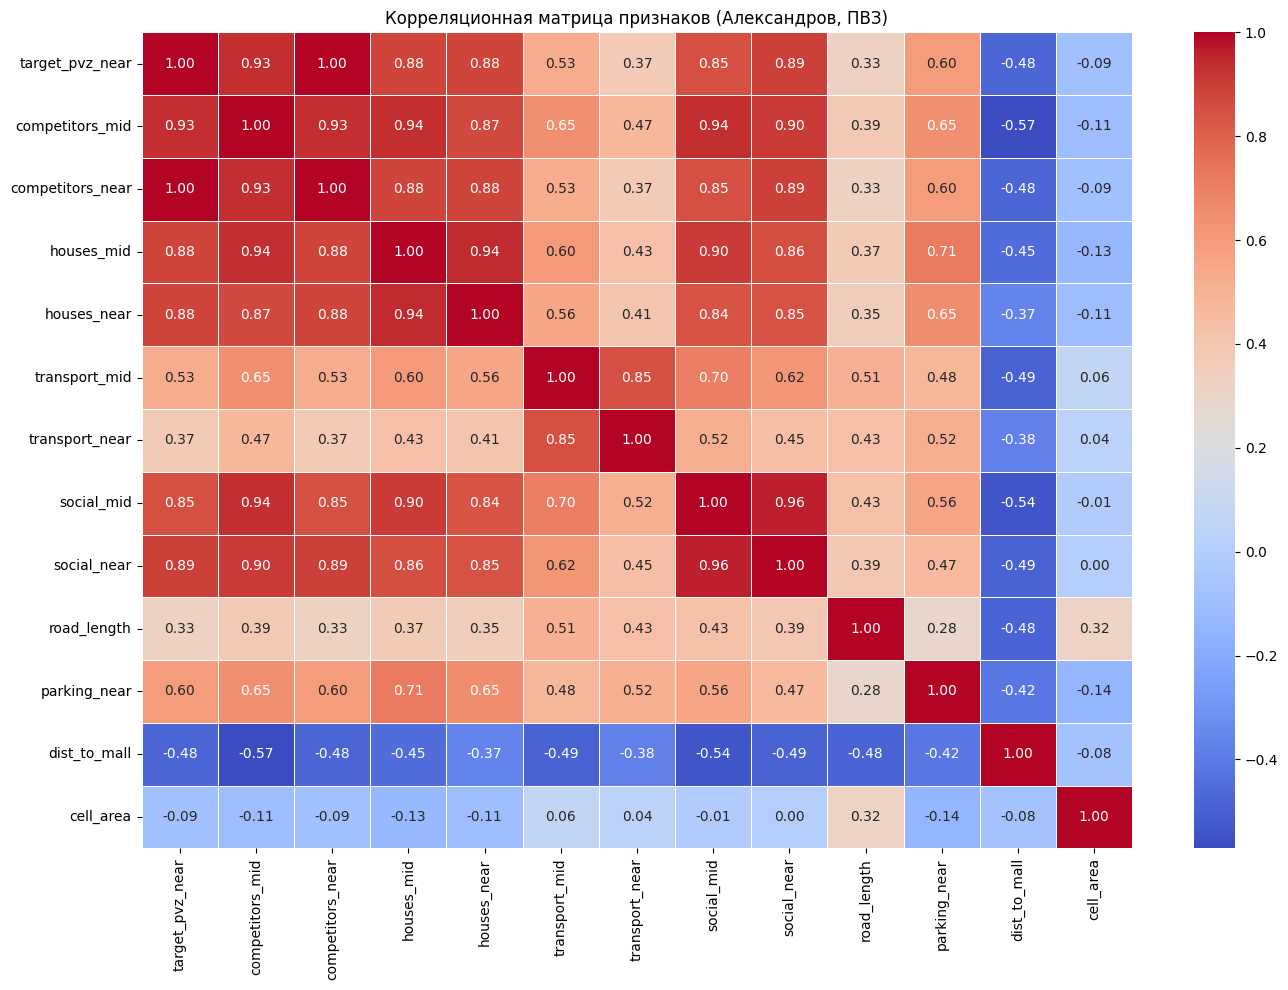

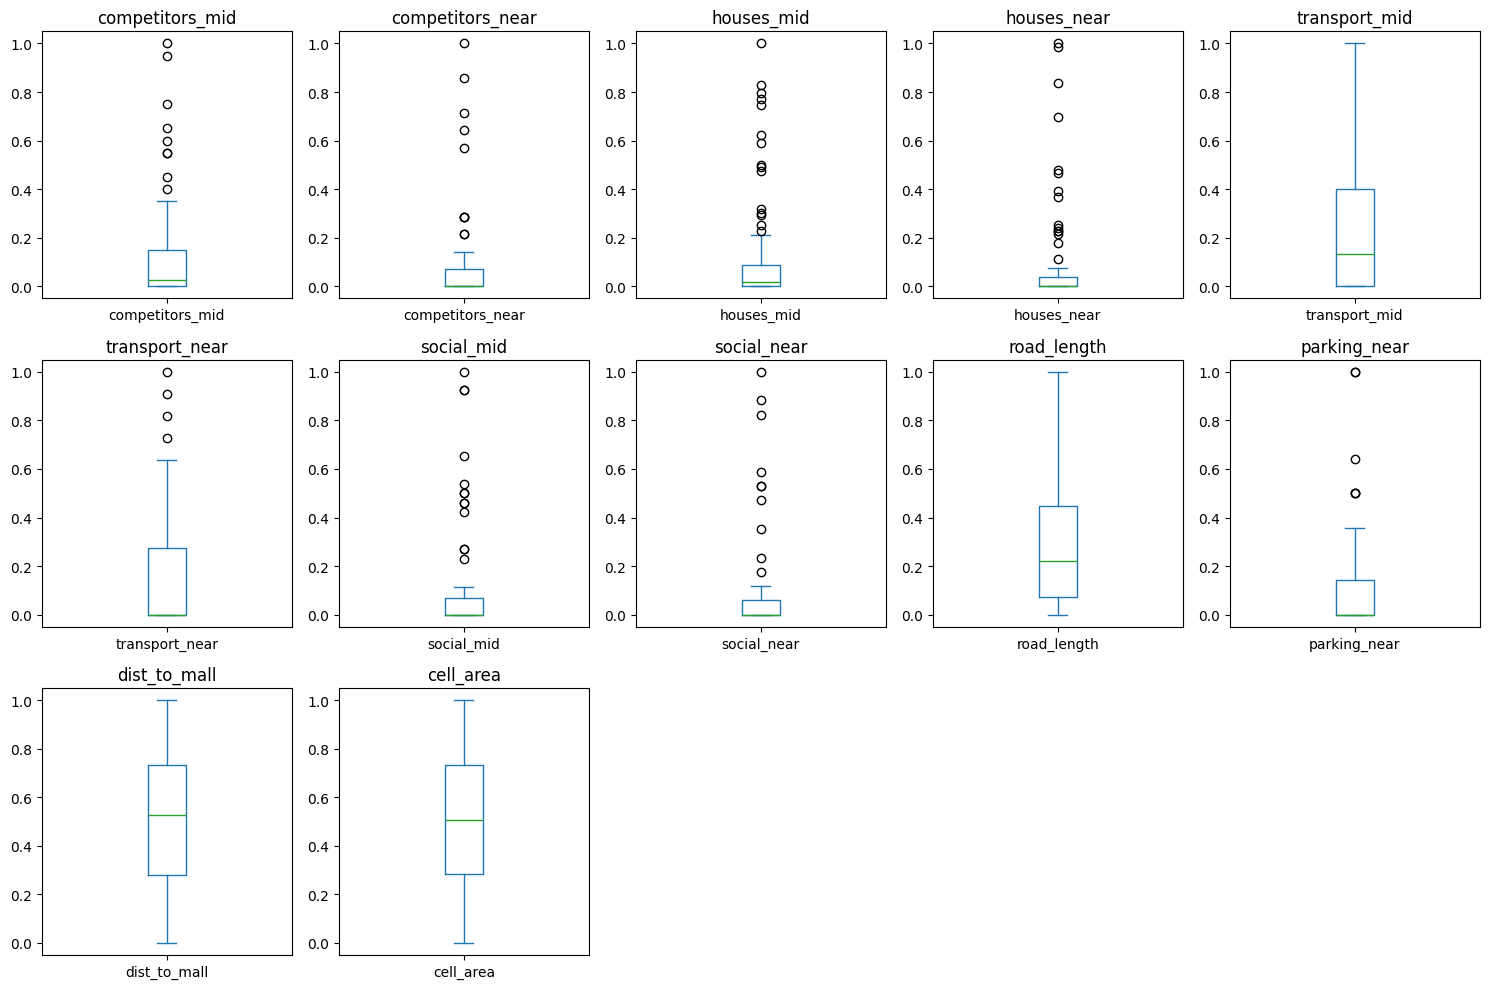

In [62]:

# Проверка данных перед визуализацией
print("Проверка данных перед визуализацией:")
print(f"NaN значений: {main_gdf[feature_names].isnull().sum().sum()}")
print(f"Типы данных: {main_gdf[feature_names].dtypes.unique()}")

# Удаляем константные столбцы из корреляционного анализа
corr_features = [f for f in feature_names if main_gdf[f].std() > 0]
print(f"\nПризнаки для корреляционного анализа (неконстантные): {len(corr_features)}")

# Корреляционная матрица
plt.figure(figsize=(14, 10))
corr_mat = main_gdf[corr_features].corr()
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица признаков (Александров, ПВЗ)')
plt.tight_layout()
plt.show()

# Box‑plot признаков (оценка выбросов)
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(features_for_scaling):
    if i < len(axes):
        if main_gdf[col].std() > 0:  # Пропускаем константные столбцы
            main_gdf[col].plot(kind='box', ax=axes[i], title=col)
        else:
            axes[i].text(0.5, 0.5, f'{col}\n(константа)',
                        ha='center', va='center', transform=axes[i].transAxes)
for j in range(len(features_for_scaling), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

In [63]:
main_gdf.to_file("alexandrov_pvz_features.geojson", driver="GeoJSON")
print("Файл сохранён: alexandrov_pvz_features.geojson")

Файл сохранён: alexandrov_pvz_features.geojson


### **Часть 3. Моделирование привлекательности локаций**



1. **Подготовка целевой переменной**:
   - Определите, как будет сформирована целевая переменная для вашей задачи (по умолчанию: наличие объектов выбранного типа в ячейке)
   - Исследуйте распределение целевой переменной и оцените её сбалансированность
   - При необходимости, предложите стратегию работы с несбалансированными данными

2. **Разработка моделей машинного обучения**:
   - Реализуйте и обучите несколько моделей (минимум 2) для предсказания привлекательности локации
   - Проведите оценку важности признаков для каждой модели
   - Сравните модели по метрикам качества и выберите наилучшую
   - **Дополнительное задание**: настройте гиперпараметры модели с помощью поиска по сетке (GridSearchCV) или случайного поиска (RandomSearchCV)

3. **Улучшение модели с помощью кластеризации**:
   - Выполните кластеризацию ячеек по их характеристикам
   - Определите оптимальное число кластеров с помощью метода локтя или силуэта
   - Визуализируйте результаты кластеризации
   - Проверьте, улучшает ли добавление информации о кластерах качество основной модели

Всего ячеек: 70
Ячеек с ПВЗ (класс 1): 25
Ячеек без ПВЗ (класс 0): 45
Доля положительных: 0.357 (35.7%)


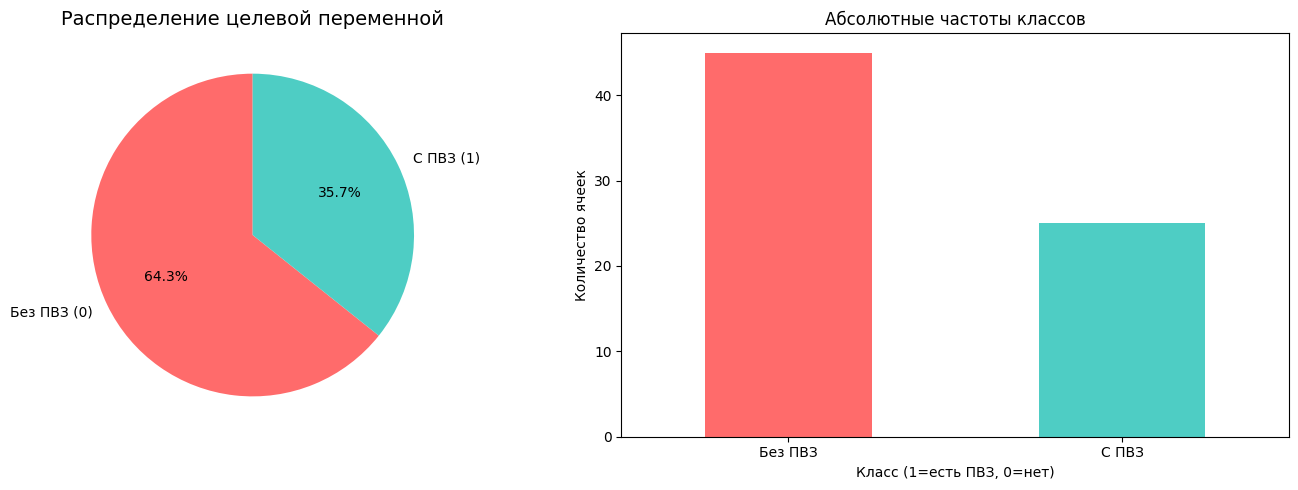


Соотношение классов 0:1 = 1.8:1
 Данные относительно сбалансированы


In [64]:
# Целевая переменная: бинарная — есть ли ПВЗ в ячейке (1) или нет (0)
# Это логичнее для задачи "где открыть новый ПВЗ"
main_gdf['has_pvz'] = (main_gdf['target_pvz_near'] > 0).astype(int)

print(f"Всего ячеек: {len(main_gdf)}")
print(f"Ячеек с ПВЗ (класс 1): {main_gdf['has_pvz'].sum()}")
print(f"Ячеек без ПВЗ (класс 0): {(main_gdf['has_pvz'] == 0).sum()}")
print(f"Доля положительных: {main_gdf['has_pvz'].mean():.3f} ({main_gdf['has_pvz'].mean()*100:.1f}%)")

# Визуализация распределения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#ff6b6b', '#4ecdc4']
main_gdf['has_pvz'].value_counts().plot(
    kind='pie', ax=axes[0], autopct='%1.1f%%',
    colors=colors, startangle=90,
    labels=['Без ПВЗ (0)', 'С ПВЗ (1)']
)
axes[0].set_ylabel('')
axes[0].set_title('Распределение целевой переменной', fontsize=14)

# Bar chart
main_gdf['has_pvz'].value_counts().plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_xlabel('Класс (1=есть ПВЗ, 0=нет)')
axes[1].set_ylabel('Количество ячеек')
axes[1].set_title('Абсолютные частоты классов')
axes[1].set_xticklabels(['Без ПВЗ', 'С ПВЗ'], rotation=0)

plt.tight_layout()
plt.show()

# Оценка сбалансированности
ratio = (main_gdf['has_pvz'] == 0).sum() / main_gdf['has_pvz'].sum()
print(f"\nСоотношение классов 0:1 = {ratio:.1f}:1")
if ratio > 3:
    print(" Данные несбалансированы! Будем использовать class_weight='balanced'")
else:
    print(" Данные относительно сбалансированы")


Статистика индекса привлекательности:
count    70.000000
mean      0.262878
std       0.258247
min       0.000000
25%       0.083723
50%       0.173885
75%       0.339667
max       1.000000
Name: pvz_score, dtype: float64


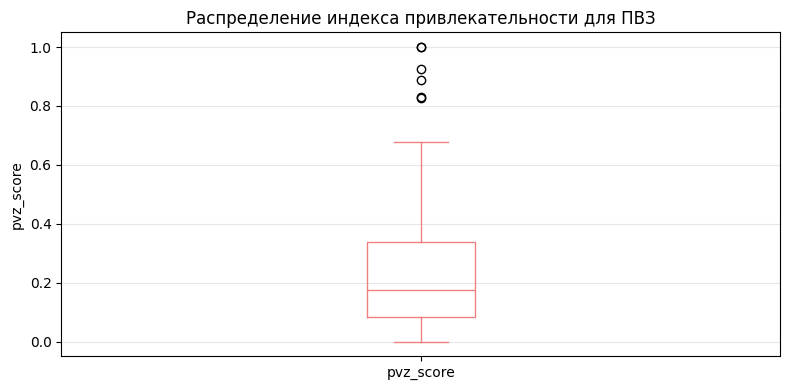

Map(center=[np.float64(56.391884149999996), np.float64(38.7180478)], controls=(ZoomControl(options=['position'…

In [65]:

# Расчёт индекса привлекательности (на нормализованных признаках)
main_gdf['pvz_score'] = (
    # Конкуренты — ОТРИЦАТЕЛЬНЫЙ фактор (штраф)
    (main_gdf['competitors_near'] * -0.30) +   # ПВЗ рядом — сильный штраф
    (main_gdf['competitors_mid'] * -0.12) +    # ПВЗ дальше — меньший штраф

    # Жилые дома — ГЛАВНЫЙ положительный фактор (спрос)
    (main_gdf['houses_near'] * 0.25) +         # дома рядом — основной поток
    (main_gdf['houses_mid'] * 0.12) +          # дома дальше — тоже важно

    # Транспортная доступность
    (main_gdf['transport_near'] * 0.15) +      # остановки рядом — очень важно
    (main_gdf['transport_mid'] * 0.06) +       # дальний транспорт

    # Социальные объекты (генерируют трафик)
    (main_gdf['social_near'] * 0.12) +         # школы, сады, поликлиники рядом
    (main_gdf['social_mid'] * 0.05) +          # соцобъекты дальше

    # Парковки (для клиентов и курьеров)
    (main_gdf['parking_near'] * 0.10) +

    # Длина дорог (связность, доступность)
    (main_gdf['road_length'] * 0.08) +

    # Расстояние до ТЦ (умеренно положительный — трафик от ТЦ)
    # Чем ближе к ТЦ, тем лучше (инвертируем: 1 - dist)
    ((1 - main_gdf['dist_to_mall']) * 0.05) +

    # Площадь ячейки (небольшая поправка)
    (main_gdf['cell_area'] * 0.02)
)

# Нормировка индекса в [0, 1]
scaler_score = MinMaxScaler()
main_gdf['pvz_score'] = scaler_score.fit_transform(
    main_gdf['pvz_score'].values.reshape(-1, 1)
).flatten()

print("\nСтатистика индекса привлекательности:")
print(main_gdf['pvz_score'].describe())

# Boxplot
plt.figure(figsize=(8, 4))
main_gdf['pvz_score'].plot(kind='box', color='lightcoral')
plt.title('Распределение индекса привлекательности для ПВЗ')
plt.ylabel('pvz_score')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Карта индекса привлекательности
map_score = leafmap.Map(
    center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2],
    zoom=13, basemap='CartoDB.Positron'
)
map_score.add_gdf(
    main_gdf.to_crs("EPSG:4326"),
    column="pvz_score",
    cmap="YlOrRd",
    legend_title="Индекс привлекательности ПВЗ",
    k=10,
    layer_name="H3 — привлекательность",
    style={"stroke": True, "weight": 0.5, "fillOpacity": 0.75}
)
map_score

In [66]:
# Признаки для моделей (все, кроме таргета и геометрии)
features_for_model = [
    'competitors_near', 'competitors_mid',
    'houses_near', 'houses_mid',
    'transport_near', 'transport_mid',
    'social_near', 'social_mid',
    'road_length', 'parking_near',
    'dist_to_mall', 'cell_area'
]

X = main_gdf[features_for_model].copy()
y_cls = main_gdf['has_pvz'].copy()        # для классификации
y_reg = main_gdf['pvz_score'].copy()      # для регрессии (index score)

print(f"Размерность X: {X.shape}")
print(f"Классы в y: {dict(y_cls.value_counts())}")
print(f"\nПервые 5 строк X:")
display(X.head())

Размерность X: (70, 12)
Классы в y: {0: np.int64(45), 1: np.int64(25)}

Первые 5 строк X:


,competitors_near,competitors_mid,houses_near,houses_mid,transport_near,transport_mid,social_near,social_mid,road_length,parking_near,dist_to_mall,cell_area
0,0.071429,0.35,0.025316,0.213115,0.818182,0.800000,0.058824,0.230769,0.177770,0.642857,0.067684,0.456571
1,0.285714,0.45,0.367089,0.622951,0.909091,0.666667,0.176471,0.500000,0.541527,1.000000,0.130288,0.411754
2,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.103395,0.000000,0.631305,0.766903
3,0.000000,0.00,0.000000,0.008197,0.181818,0.333333,0.058824,0.038462,0.186311,0.000000,0.419535,0.722006
4,0.000000,0.00,0.000000,0.049180,0.000000,0.000000,0.000000,0.000000,0.419842,0.000000,0.267065,0.354397


In [68]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)

# Разделение с учётом дисбаланса (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls, test_size=0.3, random_state=42, stratify=y_cls
)

print(f"Train: {len(X_train)} (класс 1: {y_train.sum()})")
print(f"Test:  {len(X_test)}  (класс 1: {y_test.sum()})")

# Инициализация моделей с class_weight='balanced' для борьбы с дисбалансом
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', random_state=42, max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, random_state=42
    )
}

results_cls = []

# Создаем стратифицированный сплиттер для кросс-валидации
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_proba)

    # Cross-validation
    cv_scores = cross_val_score(model, X, y_cls, cv=cv, scoring='f1')

    results_cls.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': roc,
        'CV F1 (mean)': cv_scores.mean(),
        'CV F1 (std)': cv_scores.std()
    })

    print(f"Модель: {name}")
    print(classification_report(y_test, y_pred, target_names=['Без ПВЗ', 'С ПВЗ']))

results_df = pd.DataFrame(results_cls).sort_values('F1', ascending=False)
display(results_df)

Train: 49 (класс 1: 17)
Test:  21  (класс 1: 8)
Модель: Logistic Regression
              precision    recall  f1-score   support

     Без ПВЗ       1.00      0.92      0.96        13
       С ПВЗ       0.89      1.00      0.94         8

    accuracy                           0.95        21
   macro avg       0.94      0.96      0.95        21
weighted avg       0.96      0.95      0.95        21

Модель: Random Forest
              precision    recall  f1-score   support

     Без ПВЗ       1.00      1.00      1.00        13
       С ПВЗ       1.00      1.00      1.00         8

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21

Модель: Gradient Boosting
              precision    recall  f1-score   support

     Без ПВЗ       1.00      1.00      1.00        13
       С ПВЗ       1.00      1.00      1.00         8

    accuracy                           1.00        21
   m

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV F1 (mean),CV F1 (std)
1,Random Forest,1.000000,1.000000,1.0,1.000000,1.000000,0.977778,0.044444
2,Gradient Boosting,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,0.000000
0,Logistic Regression,0.952381,0.888889,1.0,0.941176,0.990385,0.837778,0.184806


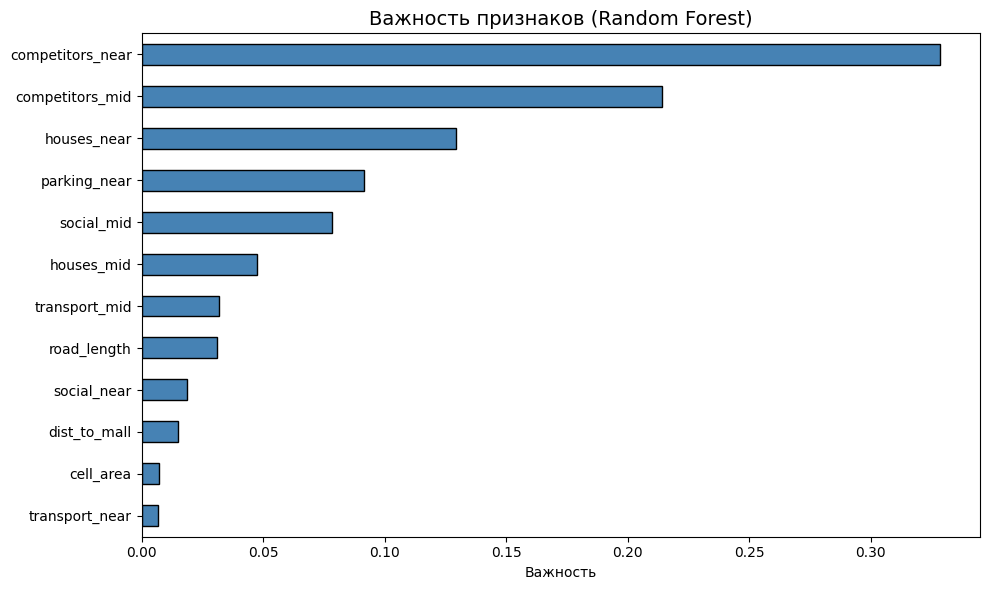

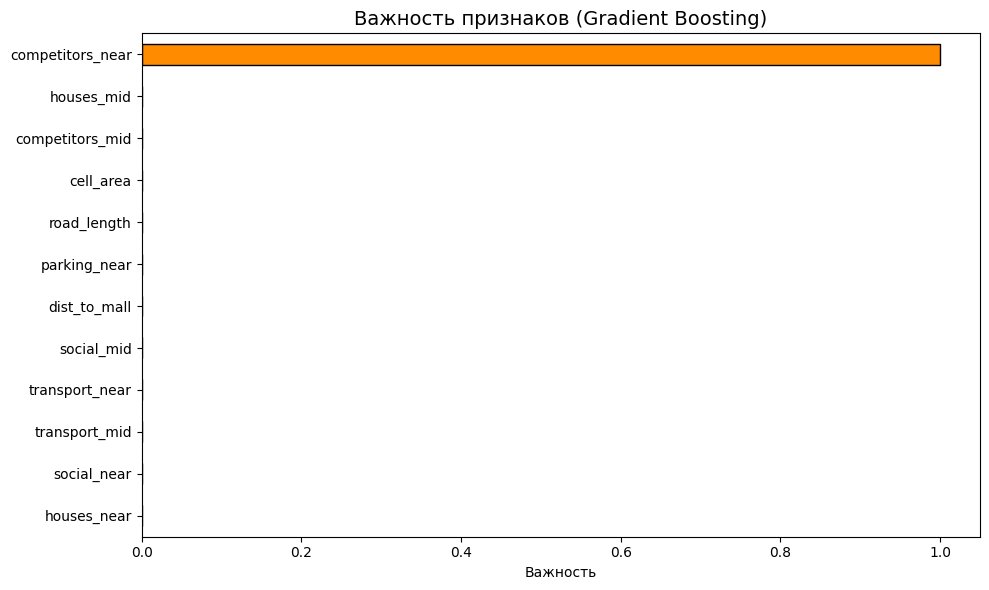

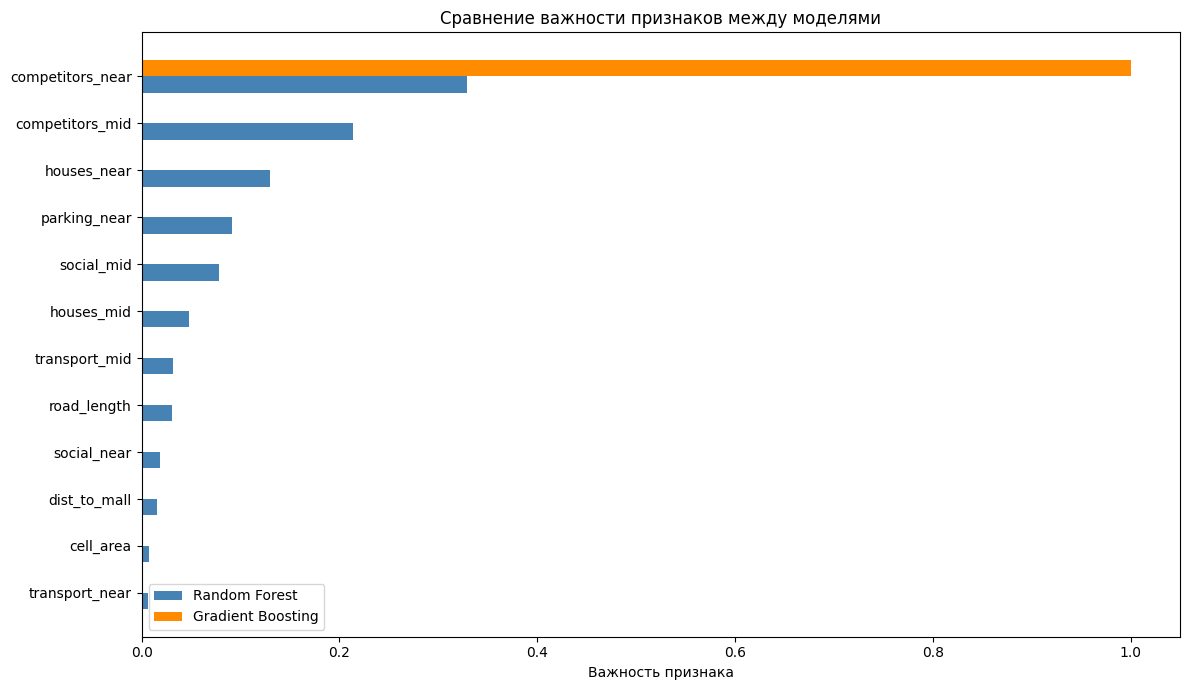

In [55]:
# Важность признаков для Random Forest
rf_model = models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=features_for_model)
feat_imp_sorted = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_imp_sorted.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Важность признаков (Random Forest)', fontsize=14)
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

# Важность для Gradient Boosting
gb_model = models['Gradient Boosting']
feat_imp_gb = pd.Series(gb_model.feature_importances_, index=features_for_model)
feat_imp_gb_sorted = feat_imp_gb.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_imp_gb_sorted.plot(kind='barh', color='darkorange', edgecolor='black')
plt.title('Важность признаков (Gradient Boosting)', fontsize=14)
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

# Сравнение важностей
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(features_for_model))
width = 0.35
ax.barh(x - width/2, feat_imp_sorted.values, width, label='Random Forest', color='steelblue')
ax.barh(x + width/2, feat_imp_gb_sorted.values, width, label='Gradient Boosting', color='darkorange')
ax.set_yticks(x)
ax.set_yticklabels(feat_imp_sorted.index)
ax.set_xlabel('Важность признака')
ax.set_title('Сравнение важности признаков между моделями')
ax.legend()
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Лучший F1 (CV): 0.9714

Метрики на тестовой выборке:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1:        1.0000
  ROC-AUC:   1.0000

Улучшение F1: 0.0000


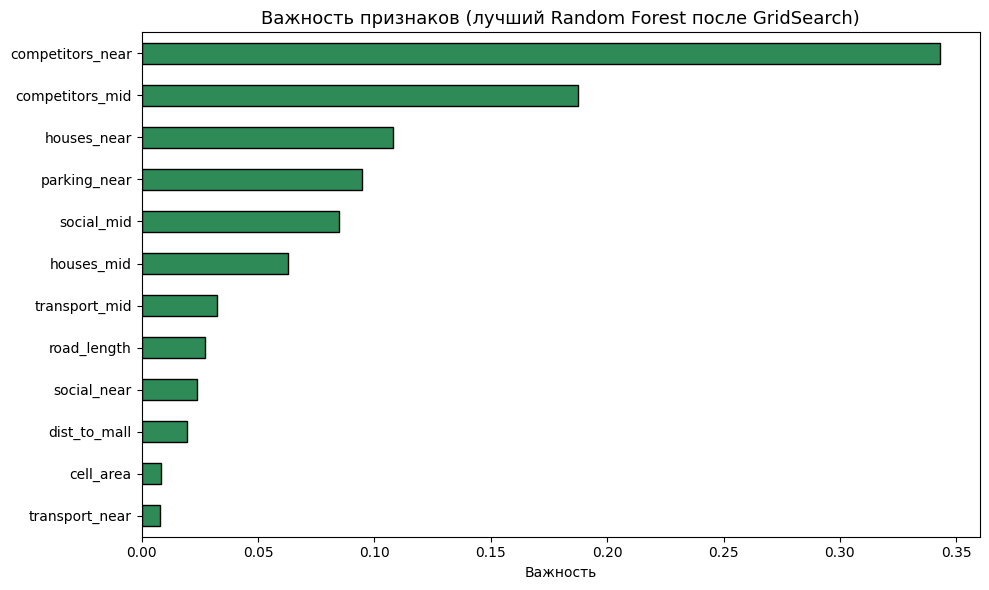

In [69]:
from sklearn.model_selection import GridSearchCV


param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший F1 (CV): {grid_search.best_score_:.4f}")

# Оценка на тесте
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

print(f"\nМетрики на тестовой выборке:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_best, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_best, zero_division=0):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_best, zero_division=0):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba_best):.4f}")

# Сравнение с базовой моделью
print(f"\nУлучшение F1: {f1_score(y_test, y_pred_best) - results_df[results_df['Model']=='Random Forest']['F1'].values[0]:.4f}")

# Важность признаков лучшей модели
feat_imp_best = pd.Series(best_rf.feature_importances_, index=features_for_model).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
feat_imp_best.plot(kind='barh', color='seagreen', edgecolor='black')
plt.title('Важность признаков (лучший Random Forest после GridSearch)', fontsize=13)
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

k=2: inertia=25.5, silhouette=0.535
k=3: inertia=20.5, silhouette=0.245
k=4: inertia=17.1, silhouette=0.249
k=5: inertia=14.8, silhouette=0.266
k=6: inertia=12.5, silhouette=0.287
k=7: inertia=11.2, silhouette=0.285
k=8: inertia=10.1, silhouette=0.268


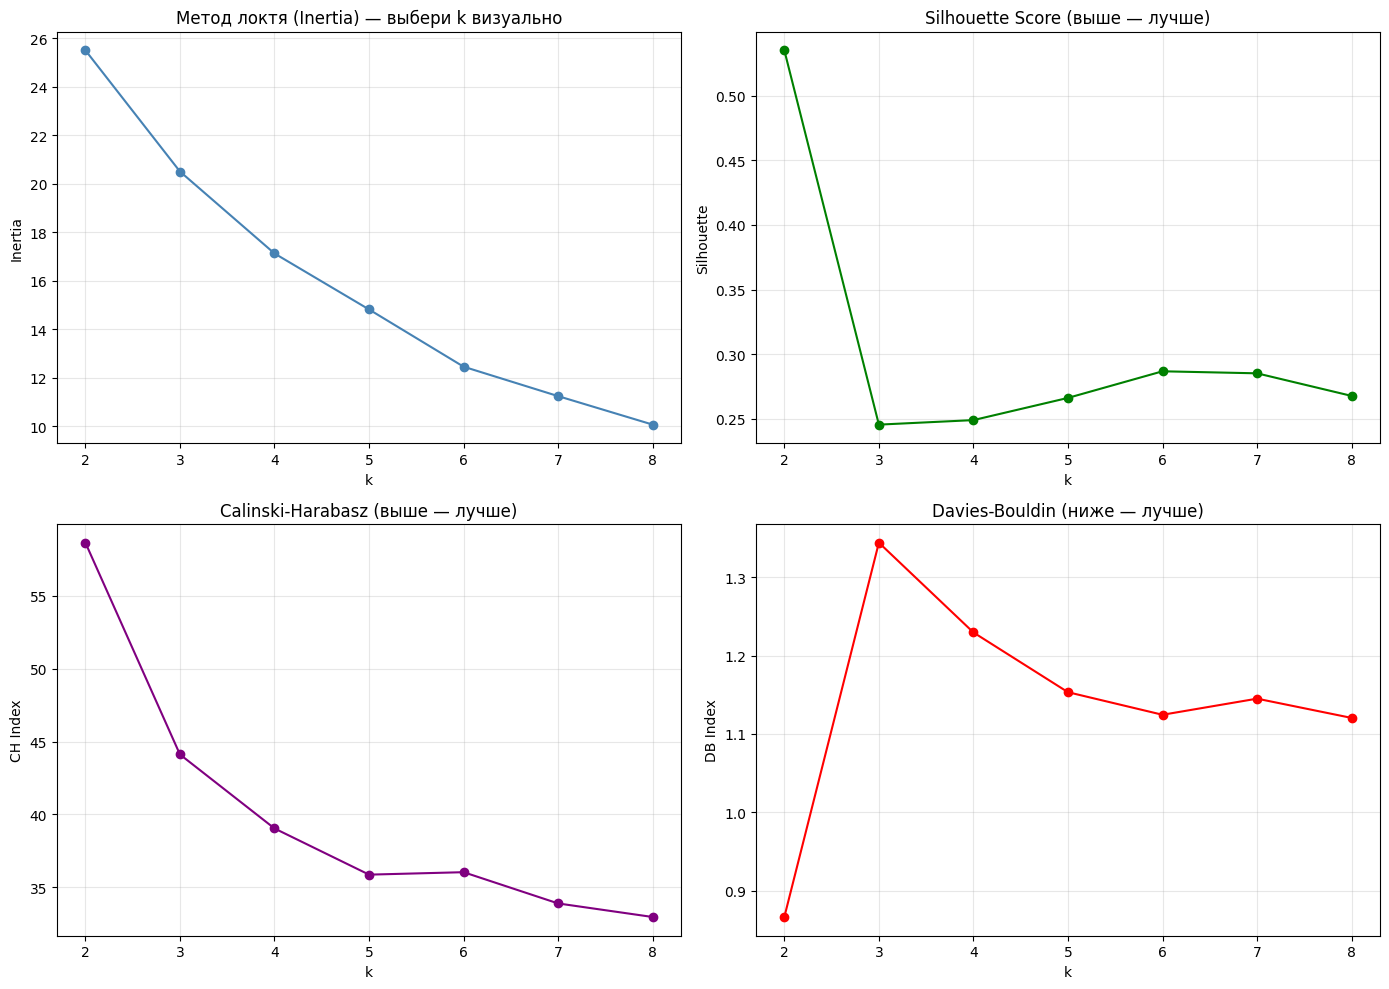


Оптимальное k по Silhouette Score: 2


In [86]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

inertias = []
sil_scores = []
ch_scores = []
db_scores = []

k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    ch_scores.append(calinski_harabasz_score(X, labels))
    db_scores.append(davies_bouldin_score(X, labels))
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={sil_scores[-1]:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(k_range, inertias, 'o-', color='steelblue')
axes[0,0].set_title('Метод локтя (Inertia) — выбери k визуально')
axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inertia')
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(k_range, sil_scores, 'o-', color='green')
axes[0,1].set_title('Silhouette Score (выше — лучше)')
axes[0,1].set_xlabel('k'); axes[0,1].set_ylabel('Silhouette')
axes[0,1].grid(alpha=0.3)

axes[1,0].plot(k_range, ch_scores, 'o-', color='purple')
axes[1,0].set_title('Calinski-Harabasz (выше — лучше)')
axes[1,0].set_xlabel('k'); axes[1,0].set_ylabel('CH Index')
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(k_range, db_scores, 'o-', color='red')
axes[1,1].set_title('Davies-Bouldin (ниже — лучше)')
axes[1,1].set_xlabel('k'); axes[1,1].set_ylabel('DB Index')
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Оптимальное k по silhouette (самая надёжная метрика)
optimal_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"\nОптимальное k по Silhouette Score: {optimal_k}")

In [87]:
# Финальная кластеризация
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
main_gdf['cluster'] = kmeans.fit_predict(X)

print(f"Распределение ячеек по кластерам:")
print(main_gdf['cluster'].value_counts().sort_index())

# Визуализация кластеров на карте
map_clusters = leafmap.Map(
    center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2],
    zoom=13, basemap='CartoDB.Positron'
)
map_clusters.add_gdf(
    main_gdf.to_crs("EPSG:4326"),
    column="cluster",
    cmap="Set2",
    legend_title=f"Кластеры (k={optimal_k})",
    layer_name="Кластеры ячеек",
    style={"stroke": True, "weight": 0.5, "fillOpacity": 0.7}
)
map_clusters

# Добавляем кластер как признак и обучаем модель заново
X_with_cluster = X.copy()
X_with_cluster['cluster'] = main_gdf['cluster']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_with_cluster, y_cls, test_size=0.3, random_state=42, stratify=y_cls
)

rf_cluster = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42
)
rf_cluster.fit(X_train2, y_train2)
y_pred_cluster = rf_cluster.predict(X_test2)
y_proba_cluster = rf_cluster.predict_proba(X_test2)[:, 1]

f1_with_cluster = f1_score(y_test2, y_pred_cluster, zero_division=0)
roc_with_cluster = roc_auc_score(y_test2, y_proba_cluster)

# Модель без кластера (для сравнения)
rf_base = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42
)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)
y_proba_base = rf_base.predict_proba(X_test)[:, 1]

f1_base = f1_score(y_test, y_pred_base, zero_division=0)
roc_base = roc_auc_score(y_test, y_proba_base)

print(f"Без кластера  — F1: {f1_base:.4f}, ROC-AUC: {roc_base:.4f}")
print(f"С кластером   — F1: {f1_with_cluster:.4f}, ROC-AUC: {roc_with_cluster:.4f}")
print(f"Изменение F1: {f1_with_cluster - f1_base:+.4f}")

Распределение ячеек по кластерам:
cluster
0    11
1    59
Name: count, dtype: int64
Без кластера  — F1: 1.0000, ROC-AUC: 1.0000
С кластером   — F1: 1.0000, ROC-AUC: 1.0000
Изменение F1: +0.0000


,competitors_near,competitors_mid,houses_near,houses_mid,transport_near,transport_mid,social_near,social_mid,road_length,parking_near,dist_to_mall,cell_area,pvz_rate,count
cluster,,,,,,,,,,,,,,
0,0.455,0.600,0.520,0.605,0.496,0.612,0.513,0.601,0.515,0.429,0.170,0.499,1.000,11
1,0.025,0.052,0.023,0.049,0.089,0.147,0.011,0.026,0.249,0.057,0.568,0.511,0.237,59


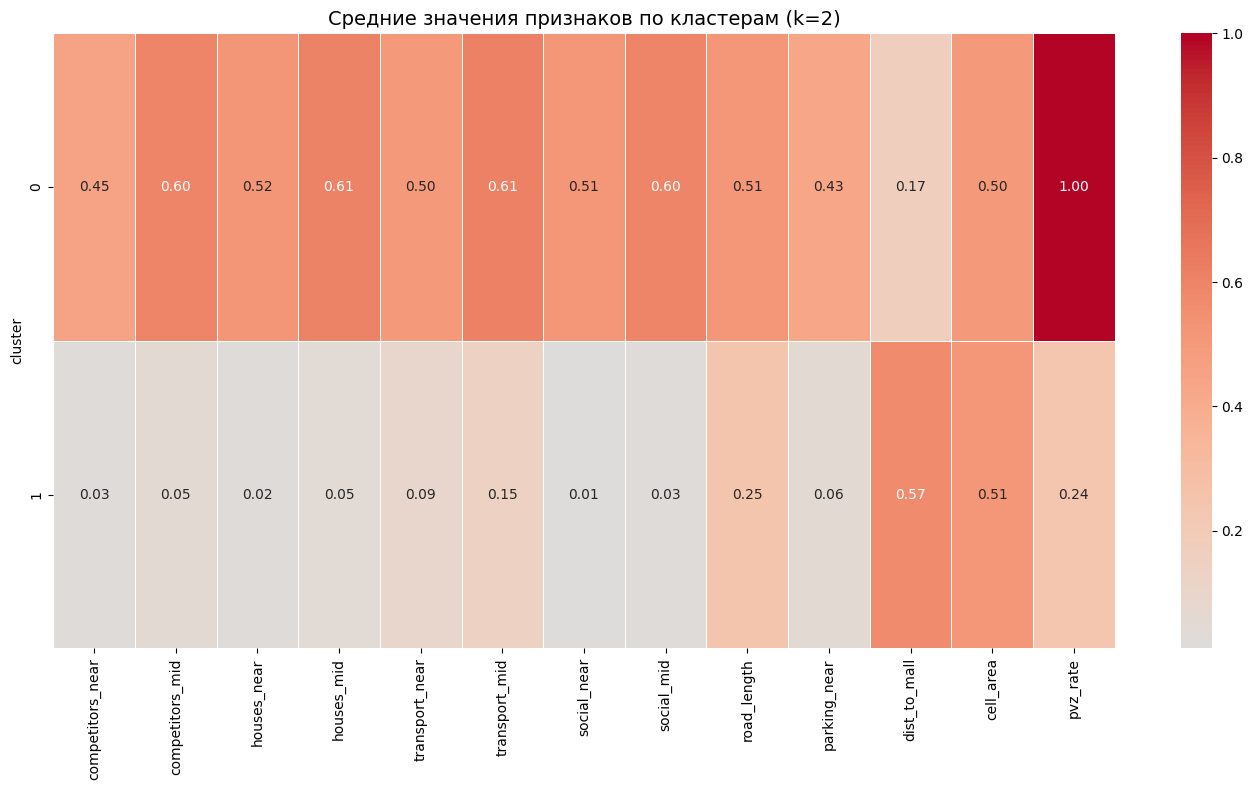

Кластер 0:  Устоявшиеся локации ПВЗ (доля ПВЗ: 100.0%, ячеек: 11)
Кластер 1:  Слабозаселённые (доля ПВЗ: 23.7%, ячеек: 59)


In [88]:
# Средние значения признаков по кластерам
cluster_profiles = main_gdf.groupby('cluster')[features_for_model].mean()

# Доля ПВЗ в каждом кластере
cluster_pvz_rate = main_gdf.groupby('cluster')['has_pvz'].mean()
cluster_profiles['pvz_rate'] = cluster_pvz_rate
cluster_profiles['count'] = main_gdf['cluster'].value_counts().sort_index()

display(cluster_profiles.round(3))

# Тепловая карта
plt.figure(figsize=(14, 8))
sns.heatmap(
    cluster_profiles.drop(columns=['count']),
    annot=True, cmap='coolwarm', fmt='.2f',
    linewidths=0.5, center=0
)
plt.title(f'Средние значения признаков по кластерам (k={optimal_k})', fontsize=14)
plt.tight_layout()
plt.show()

# Интерпретация кластеров

for cluster_id in sorted(cluster_profiles.index):
    row = cluster_profiles.loc[cluster_id]
    pvz_rate = row['pvz_rate']
    houses = row['houses_near'] + row['houses_mid']
    competitors = row['competitors_near'] + row['competitors_mid']

    if pvz_rate > 0.5:
        label = " Устоявшиеся локации ПВЗ"
    elif houses > 1.0 and competitors < 0.5:
        label = " Перспективные (много домов, мало конкурентов)"
    elif competitors > 1.0:
        label = " Высокая конкуренция"
    elif houses < 0.3:
        label = " Слабозаселённые"
    else:
        label = " Смешанные"

    print(f"Кластер {cluster_id}: {label} (доля ПВЗ: {pvz_rate:.1%}, ячеек: {int(row['count'])})")

In [89]:
# Используем лучшую модель для предсказания вероятности открытия ПВЗ во всех ячейках
best_model = best_rf  # из GridSearch
main_gdf['pvz_probability'] = best_model.predict_proba(X)[:, 1]

# Карта рекомендаций
map_recommend = leafmap.Map(
    center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2],
    zoom=13, basemap='CartoDB.Positron'
)

# Только ячейки без ПВЗ, ранжированные по вероятности
candidates = main_gdf[main_gdf['has_pvz'] == 0].to_crs("EPSG:4326").copy()

map_recommend.add_gdf(
    candidates,
    column="pvz_probability",
    cmap="RdYlGn",
    legend_title="Вероятность успеха ПВЗ",
    k=10,
    layer_name="Рекомендации",
    style={"stroke": True, "weight": 0.5, "fillOpacity": 0.8}
)

# Добавим существующие ПВЗ красным
existing_pvz = main_gdf[main_gdf['has_pvz'] == 1].to_crs("EPSG:4326")
if not existing_pvz.empty:
    map_recommend.add_gdf(
        existing_pvz,
        layer_name="Существующие ПВЗ",
        style={"color": "red", "weight": 2, "fillColor": "red", "fillOpacity": 0.6}
    )

map_recommend

# Топ-10 рекомендаций
top10 = candidates.nlargest(10, 'pvz_probability')[
    ['pvz_probability', 'houses_near', 'transport_near', 'competitors_near']
]

display(top10.round(3))

# Сохранение результата
main_gdf.to_file("alexandrov_pvz_model_results.geojson", driver="GeoJSON")
print("\n Результаты сохранены: alexandrov_pvz_model_results.geojson")

,pvz_probability,houses_near,transport_near,competitors_near
67,0.275,0.076,0.364,0.0
32,0.248,0.013,0.273,0.0
48,0.110,0.000,0.727,0.0
9,0.101,0.228,0.000,0.0
5,0.093,0.000,0.000,0.0
45,0.086,0.228,0.000,0.0
20,0.074,0.000,0.091,0.0
66,0.059,0.000,0.182,0.0
15,0.058,0.000,0.000,0.0
27,0.049,0.000,0.000,0.0



 Результаты сохранены: alexandrov_pvz_model_results.geojson


### **Часть 4. Расчет потенциала локаций и финальные рекомендации**



1. **Разработка интегрального показателя потенциала**:
   - Самостоятельно определите веса для факторов привлекательности среды и конкуренции
   - Обоснуйте выбранные веса в контексте вашего бизнеса
   - Рассчитайте итоговый потенциал для всех ячеек сетки
   - Категоризируйте потенциал для упрощения интерпретации результатов

2. **Визуализация результатов**:
   - Создайте интерактивную карту с тепловым слоем потенциала
   - Добавьте маркеры существующих объектов вашего типа бизнеса
   - Выделите топ-10 локаций с наивысшим потенциалом
   - Подготовьте отдельную карту фокуса на лучших локациях

3. **Формирование бизнес-рекомендаций**:
   - Составьте список из 5-7 конкретных локаций для размещения новых объектов
   - Для каждой рекомендуемой локации укажите:
     * Точные координаты
     * Значение потенциала
     * Ключевые характеристики локации
     * Преимущества и возможные риски размещения в данной точке
   - Подготовьте общие рекомендации по стратегии территориального развития для выбранного бизнеса


Статистика pvz_score:
count    70.000000
mean      0.262878
std       0.258247
min       0.000000
25%       0.083723
50%       0.173885
75%       0.339667
max       1.000000
Name: pvz_score, dtype: float64

  Колонка 'cluster' не найдена. Выполняем быструю кластеризацию...
 Кластеризация выполнена (k=5)

Распределение ячеек по категориям потенциала:
potential_cat
Высокий           2
Низкий           17
Очень высокий     6
Очень низкий     39
Средний           6
Name: count, dtype: int64


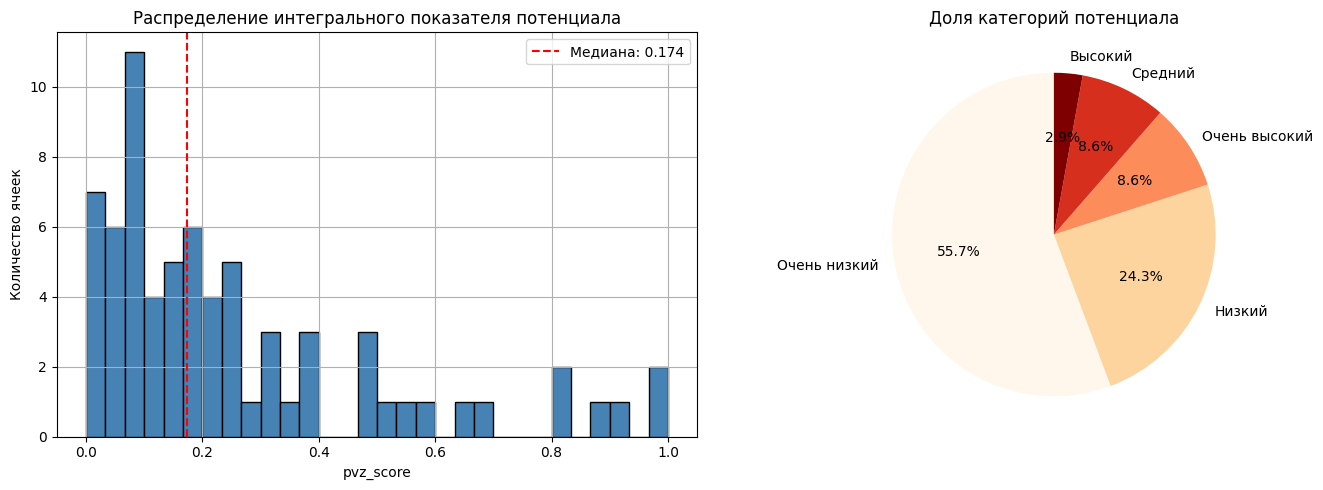

In [73]:

print(f"\nСтатистика pvz_score:")
print(main_gdf['pvz_score'].describe())

# Категоризация потенциала
clust_gdf = main_gdf.copy()

# Проверяем, есть ли колонка cluster, и создаём если нет
if 'cluster' not in clust_gdf.columns:
    print("\n  Колонка 'cluster' не найдена. Выполняем быструю кластеризацию...")
    from sklearn.cluster import KMeans

    features_for_clustering = [
        'competitors_near', 'competitors_mid',
        'houses_near', 'houses_mid',
        'transport_near', 'transport_mid',
        'social_near', 'social_mid',
        'road_length', 'parking_near',
        'dist_to_mall', 'cell_area'
    ]

    X_clust = clust_gdf[features_for_clustering].copy()
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    clust_gdf['cluster'] = kmeans.fit_predict(X_clust)
    print(f" Кластеризация выполнена (k=5)")

clust_gdf['cluster'] = clust_gdf['cluster'].astype(str)

# 5 категорий потенциала
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['Очень низкий', 'Низкий', 'Средний', 'Высокий', 'Очень высокий']

clust_gdf['potential_cat'] = pd.cut(
    clust_gdf['pvz_score'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
).astype(str)

print(f"\nРаспределение ячеек по категориям потенциала:")
print(clust_gdf['potential_cat'].value_counts().sort_index())

# Визуализация распределения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
clust_gdf['pvz_score'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].axvline(clust_gdf['pvz_score'].median(), color='red', linestyle='--',
                label=f"Медиана: {clust_gdf['pvz_score'].median():.3f}")
axes[0].set_title('Распределение интегрального показателя потенциала')
axes[0].set_xlabel('pvz_score')
axes[0].set_ylabel('Количество ячеек')
axes[0].legend()

# Pie chart по категориям
clust_gdf['potential_cat'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    cmap='OrRd', startangle=90
)
axes[1].set_ylabel('')
axes[1].set_title('Доля категорий потенциала')

plt.tight_layout()
plt.show()

In [74]:

# Подготовка данных для визуализации
viz_gdf = clust_gdf.to_crs("EPSG:4326").copy()

# Центральные координаты Александрова
center_lat = (bbox[1] + bbox[3]) / 2
center_lon = (bbox[0] + bbox[2]) / 2

# Создаем карту
m4 = leafmap.Map(
    center=[center_lat, center_lon],
    zoom=13,
    basemap='CartoDB.Positron'
)

# Тепловой слой потенциала (по категориям)
m4.add_data(
    viz_gdf,
    column="potential_cat",
    cmap="OrRd",
    legend_title="Потенциал локации",
    layer_name="H3 — потенциал ПВЗ",
    scheme='EqualInterval',
    style={
        "stroke": True,
        "weight": 0.5,
        "fillOpacity": 0.7,
    },
    info_mode='on_click'
)

# Добавляем существующие ПВЗ красными маркерами
target_viz = target_gdf.to_crs("EPSG:4326").copy()
if not target_viz.empty:
    target_viz['name'] = target_viz.get('name', 'ПВЗ').fillna('ПВЗ')
    target_viz['brand'] = target_viz.get('brand', 'unknown').fillna('unknown')
    m4.add_gdf(
        target_viz,
        layer_name='Существующие ПВЗ',
        info_mode='on_click',
        style={"color": "red", "weight": 2, "fillColor": "red", "fillOpacity": 0.8}
    )

print(f"Добавлено {len(viz_gdf)} ячеек H3")
print(f"Добавлено {len(target_viz)} существующих ПВЗ")

m4

Добавлено 70 ячеек H3
Добавлено 43 существующих ПВЗ


Map(center=[np.float64(56.391884149999996), np.float64(38.7180478)], controls=(ZoomControl(options=['position'…

Ячеек-кандидатов (без ПВЗ): 45
Ошибка для 613277634444394495: module 'h3.api.numpy_int' has no attribute 'cell_to_latlng'
Ошибка для 613277634450685951: module 'h3.api.numpy_int' has no attribute 'cell_to_latlng'
Ошибка для 613277634375188479: module 'h3.api.numpy_int' has no attribute 'cell_to_latlng'
Ошибка для 613277634436005887: module 'h3.api.numpy_int' has no attribute 'cell_to_latlng'
Ошибка для 613277634192736255: module 'h3.api.numpy_int' has no attribute 'cell_to_latlng'
Ошибка для 613277634182250495: module 'h3.api.numpy_int' has no attribute 'cell_to_latlng'
Ошибка для 613277634425520127: module 'h3.api.numpy_int' has no attribute 'cell_to_latlng'
Ошибка для 613277634429714431: module 'h3.api.numpy_int' has no attribute 'cell_to_latlng'
Ошибка для 613277634379382783: module 'h3.api.numpy_int' has no attribute 'cell_to_latlng'
Ошибка для 613277634127724543: module 'h3.api.numpy_int' has no attribute 'cell_to_latlng'


,h3_index,pvz_score,potential_cat,cluster,houses_near,houses_mid,transport_near,competitors_near,competitors_mid,center_lat,center_lon
67,613277634444394495,0.493,Средний,3,0.076,0.057,0.364,0.0,0.00,None,None
48,613277634450685951,0.384,Низкий,0,0.000,0.000,0.727,0.0,0.10,None,None
38,613277634375188479,0.344,Низкий,3,0.000,0.000,0.182,0.0,0.00,None,None
66,613277634436005887,0.326,Низкий,3,0.000,0.074,0.182,0.0,0.00,None,None
53,613277634192736255,0.326,Низкий,3,0.000,0.008,0.364,0.0,0.00,None,None
32,613277634182250495,0.313,Низкий,3,0.013,0.008,0.273,0.0,0.05,None,None
45,613277634425520127,0.285,Низкий,0,0.228,0.303,0.000,0.0,0.05,None,None
9,613277634429714431,0.262,Низкий,0,0.228,0.230,0.000,0.0,0.00,None,None
3,613277634379382783,0.253,Низкий,1,0.000,0.008,0.182,0.0,0.00,None,None
27,613277634127724543,0.251,Низкий,3,0.000,0.016,0.000,0.0,0.00,None,None


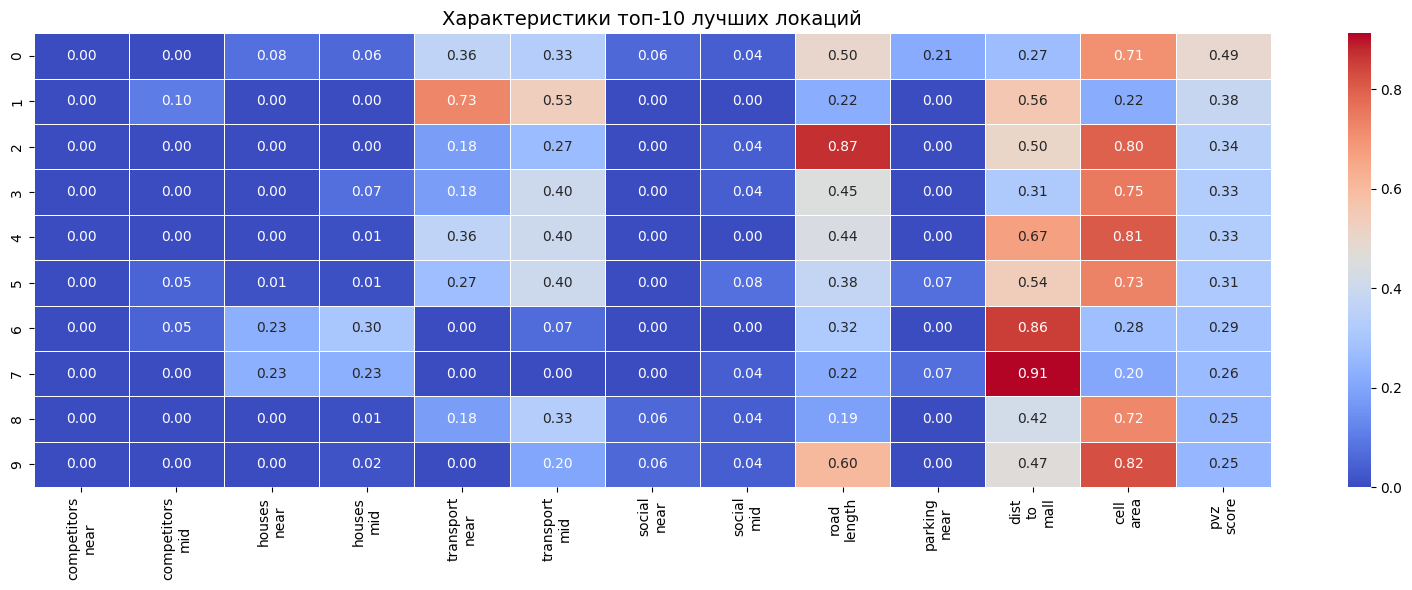

In [76]:

# Исключаем ячейки, где уже есть ПВЗ (target_pvz_near > 0)
candidates = clust_gdf[clust_gdf['target_pvz_near'] == 0].copy()
print(f"Ячеек-кандидатов (без ПВЗ): {len(candidates)}")

# Сортируем по потенциалу
best_gdf = candidates.sort_values('pvz_score', ascending=False).head(10).copy()

# Добавляем координаты центров ячеек
best_gdf['center_lat'] = None
best_gdf['center_lon'] = None

for idx, row in best_gdf.iterrows():
    try:
        lat, lng = h3.cell_to_latlng(row['h3_index'])
        best_gdf.at[idx, 'center_lat'] = lat
        best_gdf.at[idx, 'center_lon'] = lng
    except Exception as e:
        print(f"Ошибка для {row['h3_index']}: {e}")

display(best_gdf[[
    'h3_index', 'pvz_score', 'potential_cat', 'cluster',
    'houses_near', 'houses_mid', 'transport_near',
    'competitors_near', 'competitors_mid',
    'center_lat', 'center_lon'
]].round(3))

# Тепловая карта характеристик лучших локаций
fin_feat = [
    'competitors_near', 'competitors_mid',
    'houses_near', 'houses_mid',
    'transport_near', 'transport_mid',
    'social_near', 'social_mid',
    'road_length', 'parking_near',
    'dist_to_mall', 'cell_area',
    'pvz_score'
]

plt.figure(figsize=(16, 6))
sns.heatmap(
    best_gdf[fin_feat].reset_index(drop=True),
    annot=True, cmap='coolwarm', fmt='.2f',
    linewidths=0.5,
    xticklabels=[f.replace('_', '\n') for f in fin_feat]
)
plt.title('Характеристики топ-10 лучших локаций', fontsize=14)
plt.tight_layout()
plt.show()

In [78]:

# Создаем GeoDataFrame с центрами лучших локаций
df_centers = pd.DataFrame({
    'h3_id': best_gdf['h3_index'],
    'lat': best_gdf['center_lat'],
    'lng': best_gdf['center_lon'],
    'score': best_gdf['pvz_score'],
    'cat': best_gdf['potential_cat']
})

gdf_centers = gpd.GeoDataFrame(
    df_centers,
    geometry=gpd.points_from_xy(df_centers['lng'], df_centers['lat']),
    crs="EPSG:4326"
)

# Карта фокуса
m5 = leafmap.Map(
    center=[center_lat, center_lon],
    zoom=13,
    basemap='CartoDB.Positron'
)

# Лучшие ячейки (зеленая шкала)
best_viz = best_gdf.to_crs("EPSG:4326").copy()
m5.add_data(
    best_viz,
    column='pvz_score',
    cmap="Greens",
    k=10,
    layer_name="Топ-10 локаций",
    style={
        "stroke": True,
        "weight": 1.5,
        "fillOpacity": 0.75,
    },
    info_mode='on_click'
)

# Центры лучших локаций (крупные маркеры)
m5.add_gdf(
    gdf_centers,
    layer_name="Центры лучших локаций",
    info_mode='on_click',
    style={"color": "darkgreen", "weight": 2, "fillColor": "darkgreen", "fillOpacity": 0.9, "radius": 8}
)

# Все существующие ПВЗ (красные)
m5.add_gdf(
    target_viz,
    layer_name='Существующие ПВЗ',
    info_mode='on_click',
    style={"color": "red", "weight": 2, "fillColor": "red", "fillOpacity": 0.7}
)
# Все ячейки-кандидаты (полупрозрачные)
candidates_viz = candidates.to_crs("EPSG:4326").copy()
m5.add_data(
    candidates_viz,
    column='pvz_score',
    cmap="YlOrRd",
    k=10,
    layer_name="Все кандидаты",
    style={
        "stroke": False,
        "weight": 0,
        "fillOpacity": 0.3,
    },
    hover_style={
        "weight": 1,
        "fillOpacity": 0.6,
    },
    info_mode='on_click'
)

m5

Map(center=[np.float64(56.391884149999996), np.float64(38.7180478)], controls=(ZoomControl(options=['position'…

In [84]:
import requests
import time



# 1. Конвертируем best_gdf в WGS84 для получения координат
best_gdf_wgs = best_gdf.to_crs("EPSG:4326").copy()

# 2. Извлекаем координаты из геометрического центра
lats = []
lons = []
for idx, row in best_gdf_wgs.iterrows():
    center = row.geometry.centroid
    lats.append(center.y)
    lons.append(center.x)

best_gdf_wgs['center_lat'] = lats
best_gdf_wgs['center_lon'] = lons

print(f"Получено координат: {len(best_gdf_wgs)}")
print(f"Пример координат: {best_gdf_wgs['center_lat'].iloc[0]:.6f}, {best_gdf_wgs['center_lon'].iloc[0]:.6f}")

# 3. Функция обратного геокодирования
def get_address(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return "координаты недоступны"
    url = "https://nominatim.openstreetmap.org/reverse"
    params = {
        "lat": lat,
        "lon": lon,
        "format": "json",
        "zoom": 18,
        "addressdetails": 1,
        "accept-language": "ru"
    }
    headers = {"User-Agent": "PVZ-Alexandrov-Analysis/1.0"}
    try:
        r = requests.get(url, params=params, headers=headers, timeout=5)
        data = r.json()
        addr = data.get("address", {})
        street = addr.get("road", addr.get("pedestrian", addr.get("suburb", "улица не определена")))
        house = addr.get("house_number", "")
        if house:
            return f"{street}, {house}"
        return street
    except:
        return "адрес не определён"

# 4. Получаем адреса
results = []
for i, (idx, row) in enumerate(best_gdf_wgs.iterrows(), 1):
    lat = row['center_lat']
    lon = row['center_lon']
    address = get_address(lat, lon)

    results.append({
        '№': i,
        'lat': round(float(lat), 6),
        'lon': round(float(lon), 6),
        'адрес': address,
        'pvz_score': round(float(row['pvz_score']), 3),
        'houses_near': float(row['houses_near']),
        'transport_near': float(row['transport_near']),
        'competitors_near': float(row['competitors_near']),
        'social_near': float(row['social_near']),
        'parking_near': float(row['parking_near']),
        'dist_to_mall': round(float(row['dist_to_mall']), 3)
    })

    print(f"Локация #{i}: {lat:.6f}, {lon:.6f} | {address} | Score: {row['pvz_score']:.3f}")
    time.sleep(1.2)

rec_df = pd.DataFrame(results)
display(rec_df)

Получено координат: 10
Пример координат: 56.399285, 38.737712
Локация #1: 56.399285, 38.737712 | Музейный проезд, 12 | Score: 0.493
Локация #2: 56.378073, 38.692220 | Юбилейная улица | Score: 0.384
Локация #3: 56.416167, 38.725847 | улица Весны, 7А | Score: 0.344
Локация #4: 56.407727, 38.731780 | 4-я Парковая улица, 7А | Score: 0.326
Локация #5: 56.395105, 38.760788 | Кольчугинская улица, 46 | Score: 0.326
Локация #6: 56.392974, 38.752216 | 2-я Луговая улица, 57 | Score: 0.313
Локация #7: 56.365447, 38.721219 | улица Белякова | Score: 0.285
Локация #8: 56.363321, 38.712648 | Черёмушки | Score: 0.262
Локация #9: 56.414033, 38.717276 | улица не определена, 124 | Score: 0.253
Локация #10: 56.409859, 38.740351 | 2-я Полевая улица, 31 | Score: 0.251


,№,lat,lon,адрес,pvz_score,houses_near,transport_near,competitors_near,social_near,parking_near,dist_to_mall
0,1,56.399285,38.737712,"Музейный проезд, 12",0.493,0.075949,0.363636,0.0,0.058824,0.214286,0.269
1,2,56.378073,38.692220,Юбилейная улица,0.384,0.000000,0.727273,0.0,0.000000,0.000000,0.561
2,3,56.416167,38.725847,"улица Весны, 7А",0.344,0.000000,0.181818,0.0,0.000000,0.000000,0.505
3,4,56.407727,38.731780,"4-я Парковая улица, 7А",0.326,0.000000,0.181818,0.0,0.000000,0.000000,0.314
4,5,56.395105,38.760788,"Кольчугинская улица, 46",0.326,0.000000,0.363636,0.0,0.000000,0.000000,0.669
5,6,56.392974,38.752216,"2-я Луговая улица, 57",0.313,0.012658,0.272727,0.0,0.000000,0.071429,0.536
6,7,56.365447,38.721219,улица Белякова,0.285,0.227848,0.000000,0.0,0.000000,0.000000,0.855
7,8,56.363321,38.712648,Черёмушки,0.262,0.227848,0.000000,0.0,0.000000,0.071429,0.913
8,9,56.414033,38.717276,"улица не определена, 124",0.253,0.000000,0.181818,0.0,0.058824,0.000000,0.420
9,10,56.409859,38.740351,"2-я Полевая улица, 31",0.251,0.000000,0.000000,0.0,0.058824,0.000000,0.466


Необходимо открываться рядом с жилыми домами, в густонаселённых спальных районах и новых жилых комплексах Александрова. Главная логика клиента — забрать посылку по пути домой, поэтому точка должна находиться на привычном ежедневном маршруте жителей.
Нужно учитывать конкуренцию: не стоит открывать ПВЗ в одном доме или через дорогу от точки того же маркетплейса, чтобы не делить поток. Если рядом работает ПВЗ конкурентов (например, Wildberries или Ozon) — это допустимо, люди заказывают в разных местах. В таком случае нужно переманивать клиентов сервисом: просторная примерочная, вежливые сотрудники, отсутствие очередей и удобный график работы. Также нужно держаться на расстоянии минимум 400–500 метров от своих же точек.
Необходимо учитывать проходимость и транспортную доступность — очень выгодно открываться рядом с остановками общественного транспорта, школами, детскими садами и торговыми центрами, ведь так людям удобнее заходить за посылкой по пути. Обязательно наличие хотя бы небольшой парковки, так как многие клиенты забирают крупные заказы на авто.
Для начала лучше всего открываться в районах с плотной многоэтажной застройкой и постоянным проживанием. Если рассматривать локации в частном секторе на окраинах города, необходимо выяснить, сколько людей живёт там круглогодично, а сколько только летом — иначе зимой будет «мёртвый сезон». Отдельного внимания заслуживает район ж/д станции Александров-1: там высокий транзитный трафик дачников и жителей пригорода.

## **Рекомендации по выполнению**


1. Начните с малой территории для тестирования кода и методологии, затем расширяйте анализ.
2. Используйте инкрементальный подход: сначала реализуйте базовый функционал, затем улучшайте его.
3. Регулярно сохраняйте промежуточные результаты работы.
4. При выборе признаков опирайтесь не только на учебный материал, но и на научные статьи по геоанализу и геомаркетингу.
5. Обращайте внимание на особенности территории и уникальные характеристики выбранного бизнеса.
6. Для оценки результатов старайтесь сопоставить их с реальным расположением успешных объектов аналогичного бизнеса.